# Lab 1 — Section 3.4: OpenCV (cv2)
OpenCV is a full computer vision library — much more powerful than Pillow but slightly more technical.  
The biggest thing to remember: **OpenCV reads images in BGR order, not RGB.**  
That means the color channels are flipped compared to what Pillow (and most of the world) expects.

## Open and inspect the image

In [ ]:
import cv2
import numpy as np
import os
from PIL import Image  # only used to display images inline in Jupyter

os.makedirs('../outputs', exist_ok=True)

img_bgr = cv2.imread('../data/sample_image.png')  # OpenCV reads as BGR by default

# shape = (height, width, channels) — notice: height comes first, opposite of Pillow
print('Shape (H, W, C):', img_bgr.shape)
print('Data type:', img_bgr.dtype)  # uint8 = values from 0 to 255

Shape (H, W, C): (512, 512, 3)
Data type: uint8


## Why can't I just type `img_bgr` to display it?
Unlike Pillow, OpenCV images are just NumPy arrays — Jupyter doesn't know how to show them directly.  
We convert to RGB first, then wrap it in a Pillow Image just for display.

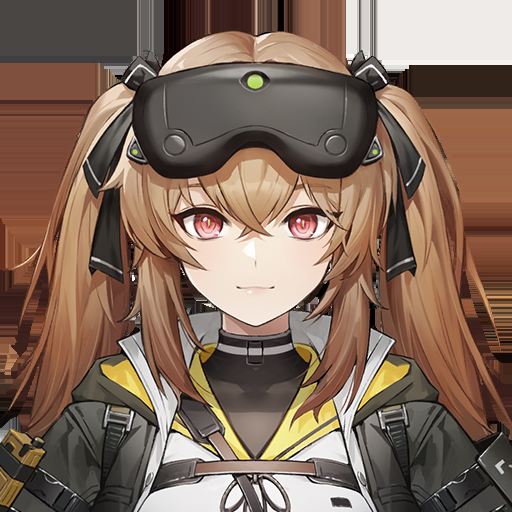

In [2]:
# cv2.COLOR_BGR2RGB swaps the Blue and Red channels to get correct colors
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Image.fromarray(img_rgb)  # wrap in Pillow just to display inline

## Convert to grayscale
`cv2.cvtColor()` is OpenCV's all-purpose color converter — you just pass it a flag telling it what to convert.

Grayscale shape: (512, 512)


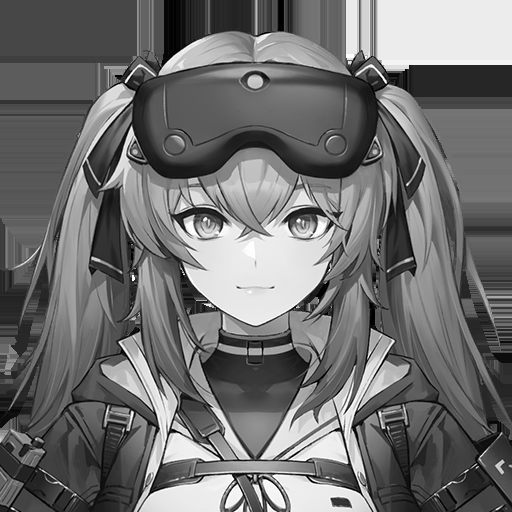

In [ ]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print('Grayscale shape:', img_gray.shape)  # (H, W) — no third dimension, no color channel

cv2.imwrite('../outputs/sample_image_gray_opencv.png', img_gray)

Image.fromarray(img_gray)  # display inline

## What happens if you display the BGR image without converting?
Pillow assumes RGB — so if we feed it the raw BGR array, red and blue channels get swapped.

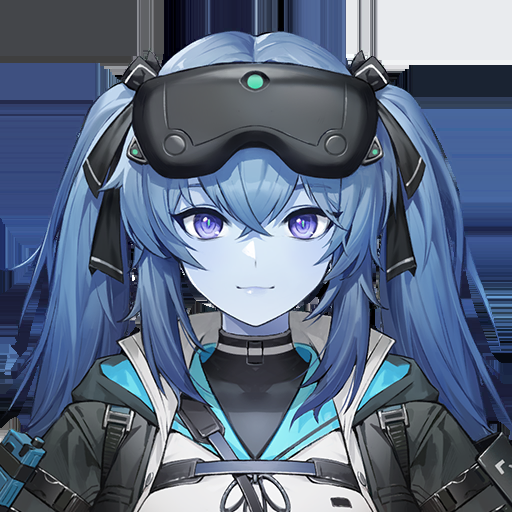

In [4]:
# this will look color-shifted (blue tones where red should be)
Image.fromarray(img_bgr)

The skin tones look bluish — that's the BGR/RGB mismatch. Always convert before displaying.

---
## 🔬 Extra things I tried

### Looking at pixel values directly

In [5]:
# OpenCV indexing is [row, col] which is [y, x] — opposite of (x, y) in Pillow
px = img_bgr[0, 0]  # top-left pixel
print('Pixel at [0,0] in BGR:', px)
print('  Blue:', px[0], '| Green:', px[1], '| Red:', px[2])

# same pixel from the RGB version — notice B and R are swapped
px_rgb = img_rgb[0, 0]
print('Pixel at [0,0] in RGB:', px_rgb)
print('  Red:', px_rgb[0], '| Green:', px_rgb[1], '| Blue:', px_rgb[2])

Pixel at [0,0] in BGR: [68 70 74]
  Blue: 68 | Green: 70 | Red: 74
Pixel at [0,0] in RGB: [74 70 68]
  Red: 74 | Green: 70 | Blue: 68


### Splitting into individual color channels
I wanted to see what each channel looks like on its own.

Showing the RED channel only:


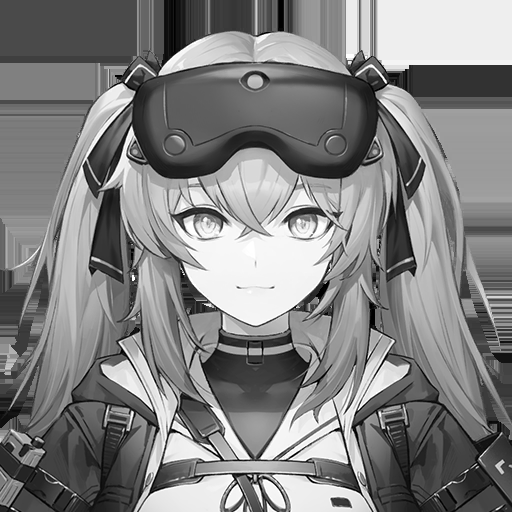

Showing the BLUE channel only:


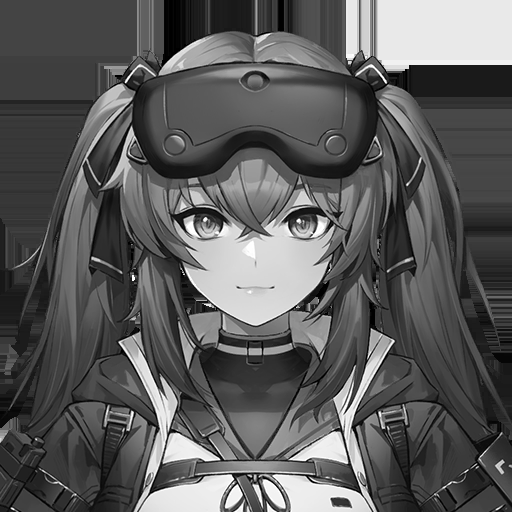

In [6]:
# cv2.split() separates the 3 channels into individual grayscale images
b, g, r = cv2.split(img_bgr)

print('Showing the RED channel only:')
display(Image.fromarray(r))

print('Showing the BLUE channel only:')
display(Image.fromarray(b))

Bright areas in each channel = that color is strong there.  
Dark areas = that color is weak or absent.

### What does the image look like in HSV color space?
HSV separates **Hue** (the actual color), **Saturation** (how vivid), and **Value** (brightness).  
It's more useful than RGB for tasks like detecting a specific color.

Hue channel (which color):


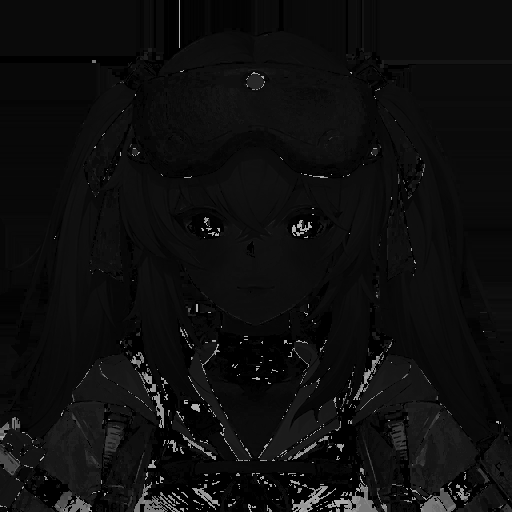

Value channel (brightness) — looks similar to grayscale:


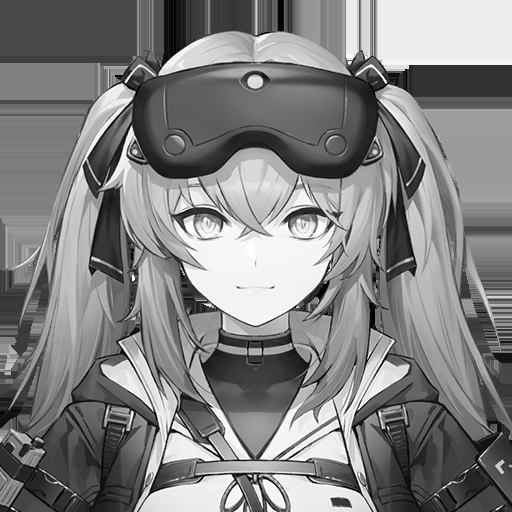

In [7]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

print('Hue channel (which color):')
display(Image.fromarray(h))

print('Value channel (brightness) — looks similar to grayscale:')
display(Image.fromarray(v))